In [ ]:
import tensorflow as tf
from tensorflow.keras import models,layers

import matplotlib.pyplot as plt

BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 50


In [ ]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/home/user/tomato project/training",
    shuffle = True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 12692 files belonging to 9 classes.


2026-03-21 16:31:05.773375: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
class_names = dataset.class_names
class_names

['Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

(32, 256, 256, 3)
[8 4 1 4 1 8 5 6 2 4 0 0 6 6 5 2 0 0 6 0 0 2 0 2 2 4 0 4 0 3 4 3]


2026-03-21 16:31:31.846350: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


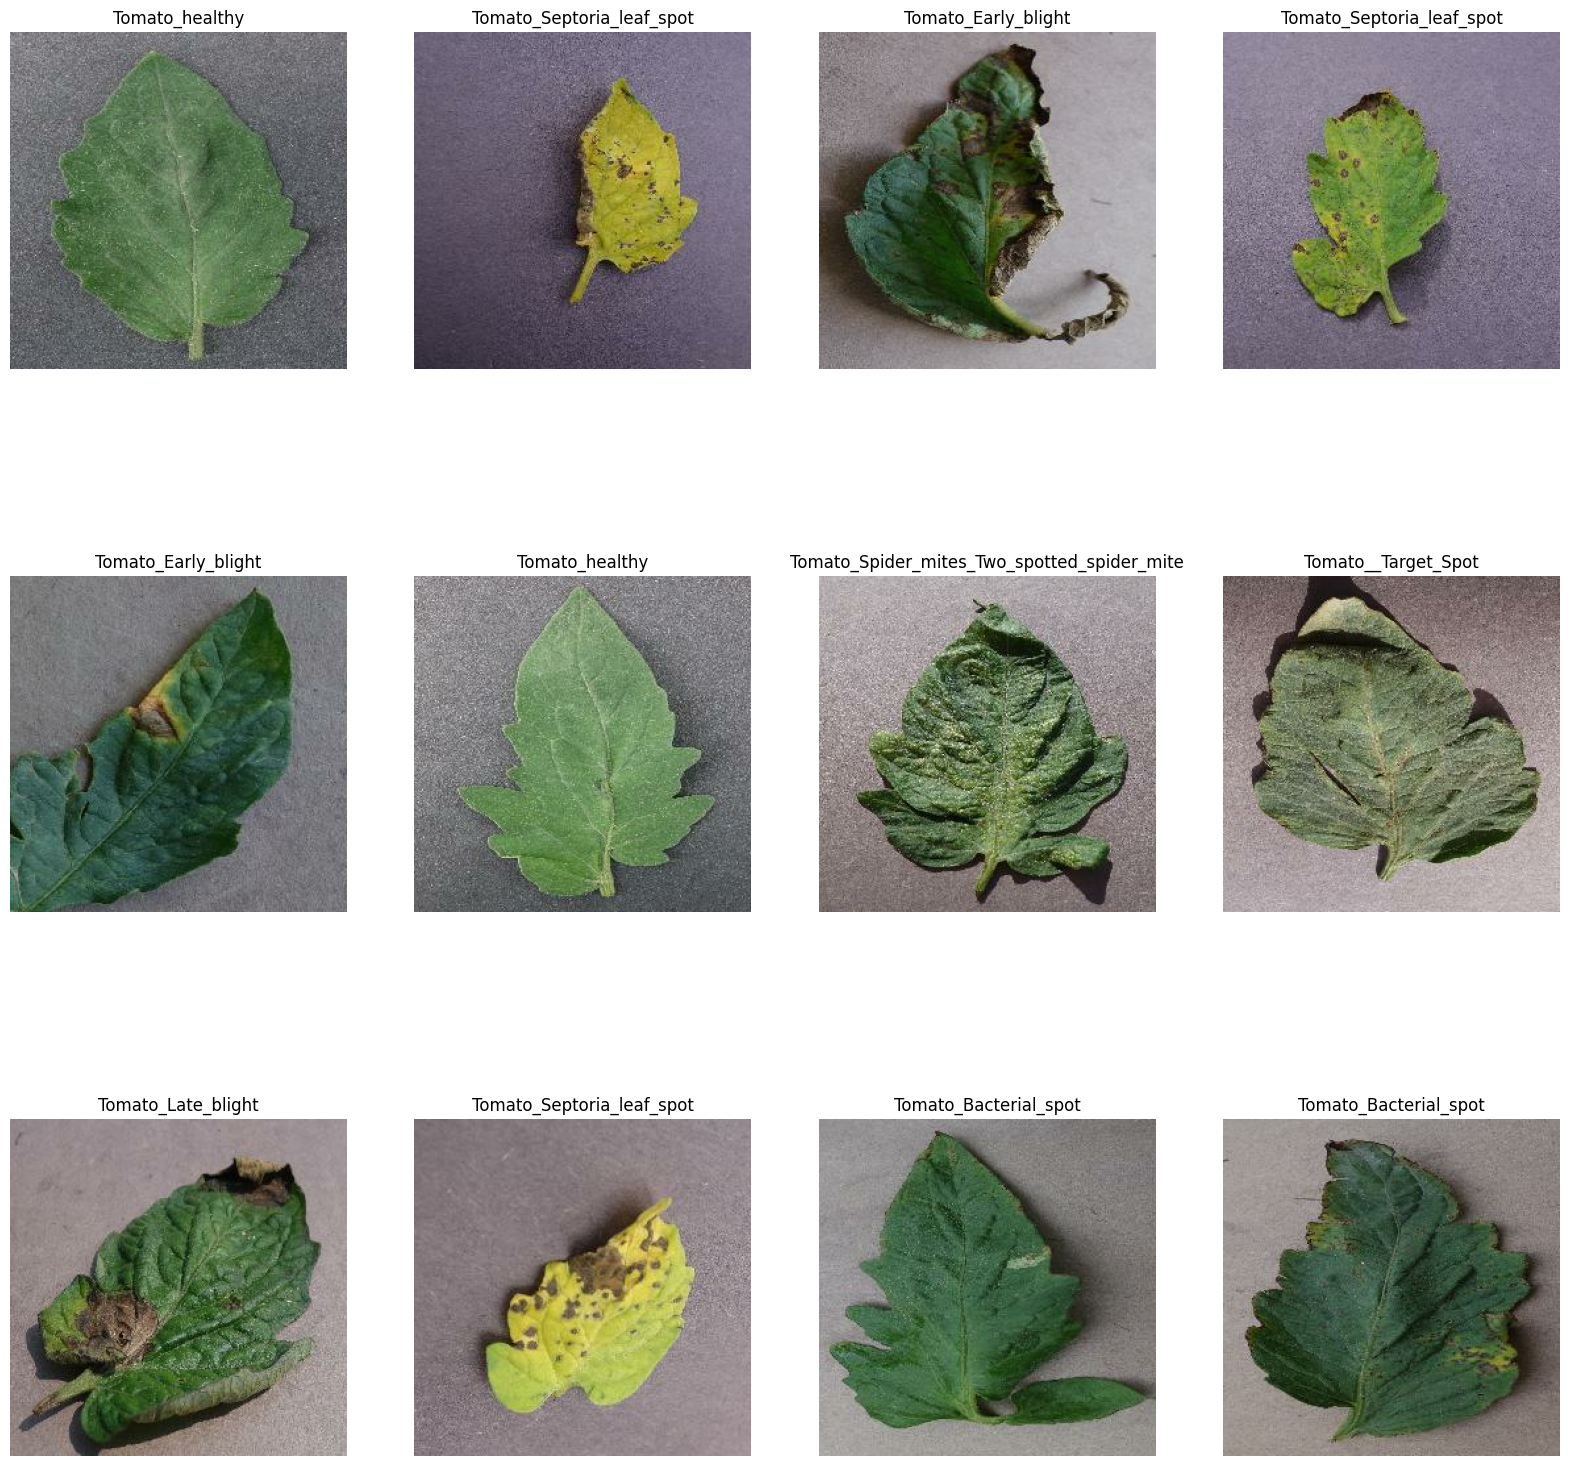

In [ ]:
plt.figure(figsize=(20,20))
for image_batch, labels_batch in dataset.take(1):
  print(image_batch.shape)
  print(labels_batch.numpy())

  for i in range(12):
    ax=plt.subplot(3,4,i+1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(class_names[labels_batch[i]])
    plt.axis("off")

In [ ]:
#  80% ==> train
#  20% ==> test
#   10% ==> validation
#   10% ==> test
train_size = 0.8
len(dataset)*train_size

317.6

In [ ]:
train_ds = dataset.take(317)
len(train_ds)

317

In [ ]:
test_ds = dataset.skip(318)
len(test_ds)

79

In [ ]:
val_size = 0.1
len(dataset)*val_size

39.7

In [ ]:
val_ds = test_ds.take(39)
len(val_ds)

39

In [ ]:
test_ds = test_ds.skip(39)
len(test_ds)

40

In [ ]:
def get_dataset_partitions_tf(dataset, train_split = 0.8, val_split = 0.1, test_split = 0.1, shuffle = True, shuffle_size = 10000):
  assert(train_split+val_split+test_split == 1)

  ds_size = len(dataset)

  if shuffle:
    ds = dataset.shuffle(shuffle_size, seed = 12)

  train_size = int(train_split*ds_size)
  val_size = int(val_split*ds_size)

  train_ds = ds.take(train_size)
  val_ds = ds.skip(train_size).take(val_size)
  test_ds = ds.skip(train_size).skip(val_size)

  return train_ds, test_ds, val_ds


In [ ]:
train_ds, test_ds, val_ds = get_dataset_partitions_tf(dataset)
print(len(train_ds))
print(len(val_ds))
print(len(test_ds))

317
39
41


In [ ]:
for image_batch, labels_batch in dataset.take(1):
  print(image_batch[0].numpy()/255,'\n')
  print(image_batch[0].shape)

[[[0.6627451  0.62352943 0.61960787]
  [0.5882353  0.54901963 0.54509807]
  [0.6627451  0.61960787 0.6117647 ]
  ...
  [0.7294118  0.70980394 0.69803923]
  [0.72156864 0.7019608  0.6901961 ]
  [0.7176471  0.69803923 0.6862745 ]]

 [[0.6784314  0.6392157  0.63529414]
  [0.59607846 0.5568628  0.5529412 ]
  [0.72156864 0.6784314  0.67058825]
  ...
  [0.75686276 0.7372549  0.7254902 ]
  [0.7529412  0.73333335 0.72156864]
  [0.7490196  0.7294118  0.7176471 ]]

 [[0.79607844 0.75686276 0.7529412 ]
  [0.6901961  0.6509804  0.64705884]
  [0.81960785 0.7764706  0.76862746]
  ...
  [0.7372549  0.7176471  0.7058824 ]
  [0.73333335 0.7137255  0.7019608 ]
  [0.73333335 0.7137255  0.7019608 ]]

 ...

 [[0.8039216  0.78431374 0.8       ]
  [0.88235295 0.8627451  0.8784314 ]
  [0.80784315 0.7882353  0.8039216 ]
  ...
  [0.9019608  0.8980392  0.91764706]
  [0.9019608  0.8980392  0.91764706]
  [0.9019608  0.8980392  0.91764706]]

 [[0.9019608  0.88235295 0.8980392 ]
  [0.80784315 0.7882353  0.8039216 ]


2026-03-21 16:32:48.428468: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
]
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
]
)

In [ ]:
n_classes = 9

model = models.Sequential([
    layers.Input(batch_shape=(BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),

    resize_and_rescale,
    data_augmentation,

    layers.Conv2D(32, kernel_size = (3,3), activation = 'relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, kernel_size = (3,3), activation = 'relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, kernel_size = (3,3), activation = 'relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, kernel_size = (3, 3), activation = 'relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, kernel_size = (3, 3), activation = 'relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, kernel_size = (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation = 'relu'),
    layers.Dense(n_classes, activation = 'softmax')

])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 9)                │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,137 (719.29 KB)

 Trainable params: 184,137 (719.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    batch_size = BATCH_SIZE,
    validation_data = val_ds,
    verbose = 1,
    epochs = EPOCHS
)

Epoch 1/50


2026-03-21 16:33:17.601345: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:13: Filling up shuffle buffer (this may take a while): 135 of 10000
